# Detecting water with radar <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment only
* **Products used:** 
[ga_s1_rtc_backscatter_experimental](https://explorer.dev.dea.ga.gov.au/products/ga_s1_rtc_backscatter_experimental)

## Background

Over 40% of the world’s population lives within 100 km of the coastline.
However, coastal environments are constantly changing, with erosion and coastal change presenting a major challenge to valuable coastal infrastructure and important ecological habitats.
Up-to-date data on the position of the coastline is essential for coastal managers to be able to identify and minimise the impacts of coastal change and erosion.

While coastlines can be mapped using optical data (demonstrated in the [Coastal Erosion notebook](Coastal_erosion.ipynb)), these images can be strongly affected by the weather, especially through the presence of clouds, which obscure the land and water below.
This can be a particular problem in cloudy regions (e.g. southern Australia) or areas where wet season clouds prevent optical satellites from taking clear images for many months of the year.

### Sentinel-1 use case

Radar observations are largely unaffected by cloud cover, so can take reliable measurements of areas in any weather.
Radar data is readily available from the ESA/EC Copernicus program's Sentinel-1 satellites.
The two satellites provide all-weather observations, with a revisit time of 6 days.
By developing a process to classify the observed pixels as either water or land, it is possible to identify the shoreline from radar data.

## Description

In this example, we use data from the Sentinel-1 satellites to build a classifier that can determine whether a pixel is water or land in radar data.
Specifically, this notebook uses an analysis-ready radar product known as backscatter, which describes the strength of the signal recieved by the satellite.
The worked example takes users through the code required to:

1. Load Sentinel-1 backscatter data for an area of interest
2. Visualise the returned data.
3. Perform pre-processing steps on the Sentinel-1 bands.
4. Design a classifier to distinguish land and water.
5. Apply the classifier to the area of interest and interpret the results.
6. Investigate how to identify coastal change or the effect of tides.

***

## Getting started

**To run this analysis**, run all the cells in the notebook, starting with the "Load packages" cell.

**After finishing the analysis**, return to the "Analysis parameters" cell, modify some values (e.g. choose a different location or time period to analyse) and re-run the analysis.
There are additional instructions on modifying the notebook at the end.

### Load packages
Load key Python packages and supporting functions for the analysis.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

import sys
sys.path.insert(1, '../Tools/')
from dea_tools.plotting import display_map


from pystac_client import Client
from odc.stac import load, configure_s3_access
from odc.geo import BoundingBox

### Connect to the datacube
Activate the datacube database, which provides functionality for loading and displaying stored Earth observation data.

In [2]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"

stac_client = Client.open(catalog)

configure_s3_access(
    cloud_defaults=True,
    aws_unsigned=True,
)

### Analysis parameters

The following cell sets the parameters, which define the area of interest and the length of time to conduct the analysis over.
The parameters are

* `latitude`: The latitude range to analyse (e.g. `(-11.288, -11.086)`).
For reasonable loading times, make sure the range spans less than ~0.1 degrees.
* `longitude`: The longitude range to analyse (e.g. `(130.324, 130.453)`).
For reasonable loading times, make sure the range spans less than ~0.1 degrees.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.
The example covers Melville Island, which sits off the coast of the Northern Territory, Australia.
The study area also contains an additional small island, which will be useful for assessing how well radar data distinguishes between land and water. 

**To run the notebook for a different area**, make sure Sentinel-1 data is available for the chosen area using the [DEA Sandbox Explorer](https://explorer.dea.ga.gov.au/products/s1_gamma0_geotif_scene).


In [3]:
# Set the central latitude and longitude
central_lat = -17.5544
central_lon = 140.7795

# Set the buffer to load around the central coordinates. 
buffer = 0.1

# Compute the bounding box for the study area
latitude = (central_lat - buffer, central_lat + buffer)
longitude = (central_lon - buffer, central_lon + buffer)


bbox = BoundingBox(
    left=central_lon - buffer,
    bottom=central_lat - buffer,
    right=central_lon + buffer,
    top=central_lat + buffer,
    crs="EPSG:4326"
)

start_date = "2024-01-01"
end_date = "2024-12-31"

## View the selected location
The next cell will display the selected area on an interactive map.
Feel free to zoom in and out to get a better understanding of the area you'll be analysing.
Clicking on any point of the map will reveal the latitude and longitude coordinates of that point.

In [ ]:
display_map(x=longitude, y=latitude)

## Load and view Sentinel-1 data

The first step in the analysis is to load Sentinel-1 backscatter data for the specified area of interest.
Since there is no time range provided, all available data will be selected.

**Please be patient**.
The data may take a few minutes to load.
The load is complete when the cell status goes from `[*]` to `[number]`.

In [4]:
collections_query = ["ga_s1_rtc_backscatter_experimental"]
date_query = f"{start_date}/{end_date}"
bbox_query = bbox.bbox

items = stac_client.search(
    collections=collections_query,
    datetime=date_query,
    bbox=bbox_query
).item_collection()

print(f"Found {len(items)} items")

Found 87 items


**Once the load is complete**, examine the data by printing it in the next cell.
The `Dimensions` argument revels the number of time steps in the data set, as well as the number of pixels in the `latitude` and `longitude` dimensions.

In [5]:
# Load our filtered data
ds_s1 = load(
    items,
    crs="EPSG:3577",
    chunks={},
    resolution=20,
    groupby="solar_day",
    intersects=bbox.boundary(),
).compute()

ds_s1 = ds_s1.odc.mask(bbox.polygon)
ds_s1 = ds_s1.dropna(dim='x', how='all').dropna(dim='y', how='all')
ds_s1

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 466MB
Dimensions:      (time: 29, y: 1177, x: 1137)
Coordinates:
  * y            (y) float64 9kB -1.893e+06 -1.893e+06 ... -1.917e+06 -1.917e+06
  * x            (x) float64 9kB 9.211e+05 9.211e+05 ... 9.438e+05 9.438e+05
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 232B 2024-01-07T20:09:16.023836 ... 20...
Data variables:
    VH           (time, y, x) float32 155MB nan nan nan nan ... nan nan nan nan
    VV           (time, y, x) float32 155MB nan nan nan nan ... nan nan nan nan
    mask         (time, y, x) float32 155MB nan nan nan nan ... nan nan nan nan

### Visualise loaded data

Sentinel-1 backscatter data has two measurements, *VV* and *VH*, which correspond to the polarisation of the light sent and received by the satellite.
*VV* refers to the satellite sending out vertically-polarised light and receiving vertically-polarised light back, whereas *VH* refers to the satellite sending out vertically-polarised light and receiving horizontally-polarised light back.
These two measurement bands can tell us different information about the area we're studying. 

When working with radar backscatter, it is common to work with the data in units of decibels (dB), rather than digital number (DN) as measured by the satellite.
To convert from DN to dB, we use the following formula:

$$
\begin{aligned}
\text{dB} = 10 \times \log_{10}(\text{DN}).
\end{aligned}
$$


In [6]:
def dB_scale(data): 
    '''Scales a xarray.DataArray with linear DN to a dB scale.'''
    # Explicitly set negative data to nan to avoid log of negative number
    negative_free_data = data.where(data >= 0, np.nan)
    return 10 * np.log10(negative_free_data)

# Scale to plot data in decibels
ds_s1["vh_dB"] = dB_scale(ds_s1.VH)
# Scale to plot data in decibels
ds_s1["vv_dB"] = dB_scale(ds_s1.VV)


#### Visualise VV band

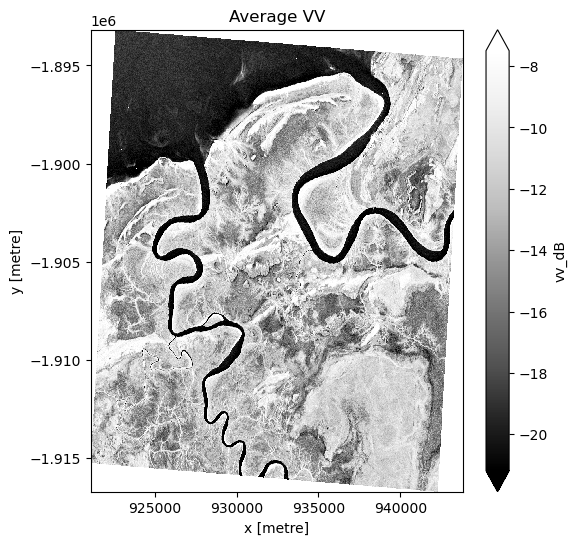

In [7]:
# Plot the average of all VV observations
mean_vv_dB = ds_s1.vv_dB.mean(dim="time")

fig = plt.figure(figsize=(6, 6))
mean_vv_dB.plot(cmap="Greys_r", robust=True)
plt.title("Average VV");

What key differences do you notice between each individual observation and the mean? What about differences between the average *VH* and *VV* bands?

Take a look back at the map image to remind yourself of the shape of the land and water of our study area. In both bands, what distinguishes the land and the water?

## Preprocessing the data through filtering

### Speckle Filtering using Lee Filter

You may have noticed that the water in the individual *VV* and *VH* images isn't a consistent colour.
The distortion you're seeing is a type of noise known as speckle, which gives the images a grainy appearence.
If we want to be able to easily decide whether any particular pixel is water or land, we need to reduce the chance of misinterpreting a water pixel as a land pixel due to the noise.

Speckle can be removed through filtering.
If interested, you can find a technical introduction to speckle filtering [here](https://earth.esa.int/documents/653194/656796/Speckle_Filtering.pdf).
For now, it is enough to know that we can filter the data using the Python function defined in the next cell:

In [8]:
def lee_filter(img, size):
    """
    Applies the Lee filter to reduce speckle noise in an image.

    Parameters:
    img (ndarray): Input image to be filtered.
    size (int): Size of the uniform filter window.

    Returns:
    ndarray: The filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2

    overall_variance = np.var(img)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output

Now that we've defined the filter, we can run it on the *VV* and *VH* data.
You might have noticed that the function takes a `size` argument.
This will change how blurred the image becomes after smoothing.
We've picked a default value for this analysis, but you can experiement with this if you're interested.

In [9]:
# Define a function to apply the Lee filter to a DataArray
def apply_lee_filter(data_array, size=7):
    """
    Applies the Lee filter to the provided DataArray.

    Parameters:
    data_array (xarray.DataArray): The data array to be filtered.
    size (int): Size of the uniform filter window. Default is 7.

    Returns:
    xarray.DataArray: The filtered data array.
    """
    data_array_filled = data_array.fillna(0)
    filtered_data = xr.apply_ufunc(
        lee_filter, data_array_filled,
        kwargs={"size": size},
        input_core_dims=[["y", "x"]],
        output_core_dims=[["y", "x"]],
        dask_gufunc_kwargs={"allow_rechunk": True},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[data_array.dtype]
    )
    return filtered_data

In [47]:
# The lee filter above doesn't handle null values
# We therefore set null values to 0 before applying the filter
valid = np.isfinite(ds_s1)
ds_s1 = ds_s1.where(valid, 0)

ds_s1["vh_dB_filtered"] = apply_lee_filter(ds_s1.vh_dB, size = 7)
ds_s1["vv_dB_filtered"] = apply_lee_filter(ds_s1.vv_dB, size = 7)

ds_s1["vh_dB_filtered"] = ds_s1["vh_dB_filtered"].where(~np.isnan(mean_vv_dB))
ds_s1["vv_dB_filtered"] = ds_s1["vv_dB_filtered"].where(~np.isnan(mean_vv_dB))

# ds_s1['HH_dB_filtered'].plot.imshow(col="time", col_wrap=3, robust=True, cmap="Greys_r")

## Designing a threshold-based water classifier

Given that the distinction between the `land` and `water` pixel value distributions is strongest in the *VH* band, we'll base our classifier on this distribution.
To separate them, we can choose a threshold: pixels with values below the threshold are water, and pixels with values above the threshold are not water (land).

There are a number of ways to determine the threshold; one is to estimate it by looking at the *VH* histogram.
From this, we might guess that $\text{threshold} = -20.0$ is a reasonable value.
Run the cell below to set the threshold.

In [68]:
from skimage.filters import threshold_otsu
x = ds_s1.vv_dB_filtered.data
x = x[~np.isnan(x)] 

threshold_vh = threshold_otsu(x)

print(threshold_vh)

-15.495751


The classifier separates data into two classes: data above the threshold and data below the threshold.
In doing this, we assume that values of both segments correspond to the same `water` and `not water` distinctions we make visually.
This can be represented with a step function:

$$  \text{water}(VH) = \left\{
     \begin{array}{lr}
       \text{True} & :   VH < \text{threshold}\\
       \text{False} & :  VH \geq \text{threshold}
     \end{array}
   \right.\\ $$  

<br>


## Histogram analysis for Sentinel-1

Backscatter distributions are plotted below as histograms.

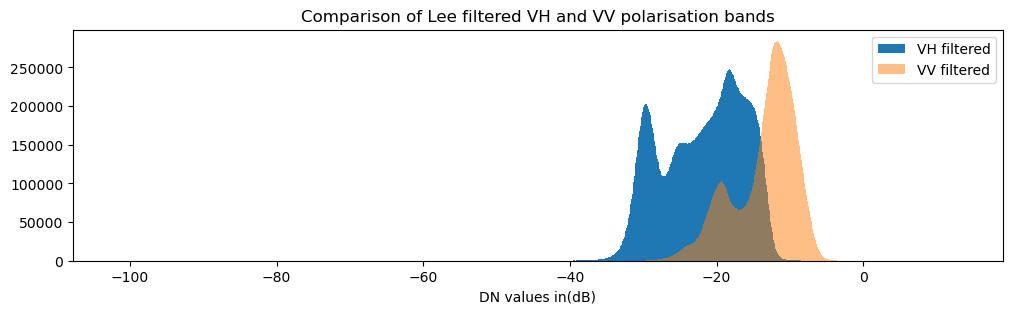

In [49]:
fig = plt.figure(figsize=(12, 3))
ds_s1.vh_dB_filtered.plot.hist(bins=1000, label="VH filtered")
ds_s1.vv_dB_filtered.plot.hist(bins=1000, label="VV filtered",alpha=0.5)
plt.legend()
plt.xlabel("DN values in(dB)")
plt.title("Comparison of Lee filtered VH and VV polarisation bands");

### Visualise threshold

To check if our chosen threshold reasonably divides the two distributions, we can add the threshold to the histogram plots we made earlier.
Run the next two cells to view two different visualisations of this.

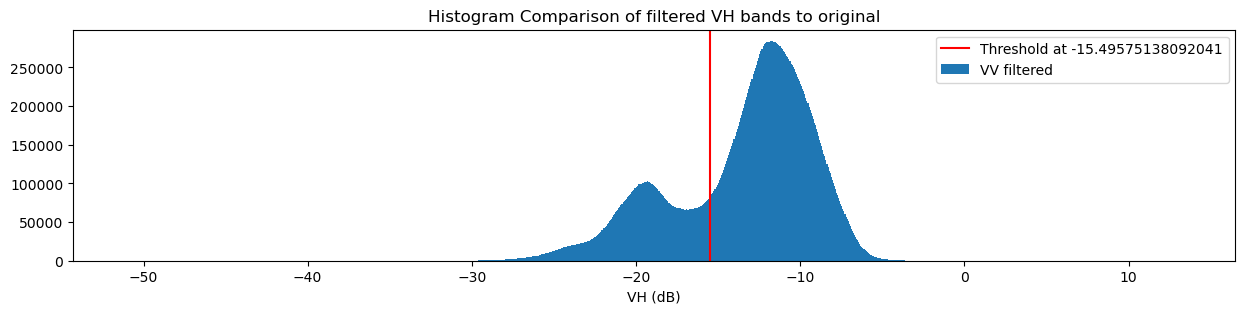

In [70]:
fig = plt.figure(figsize=(15, 3))
plt.axvline(x=threshold_vh, label=f"Threshold at {threshold_vh}", color="red")
ds_s1.vv_dB_filtered.plot.hist(bins=1000, label="VV filtered")
plt.legend()
plt.xlabel("VH (dB)")
plt.title("Histogram Comparison of filtered VH bands to original")
plt.show()

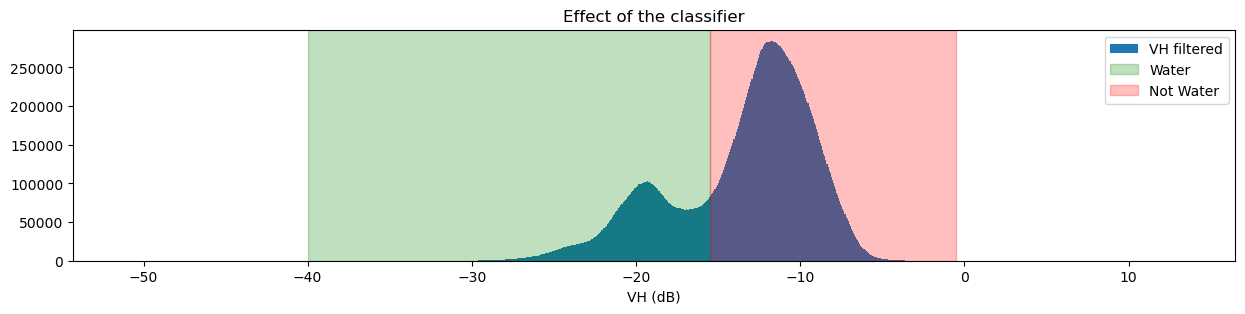

In [71]:
fig, ax = plt.subplots(figsize=(15, 3))
ds_s1.vv_dB_filtered.plot.hist(bins=1000, label="VH filtered")
ax.axvspan(xmin=-40.0, xmax=threshold_vh, alpha=0.25, color="green", label="Water")
ax.axvspan(xmin=threshold_vh,
           xmax=-0.5,
           alpha=0.25,
           color="red",
           label="Not Water")
plt.legend()
plt.xlabel("VH (dB)")
plt.title("Effect of the classifier")
plt.show()

If you're curious about how changing the threshold impacts the classifier, try changing the threshold value and running the previous two cells again.

## Build and apply the classifier

Now that we know the threshold, we can write a function to only return the pixels that are classified as water. The basic steps that the function will perform are:

1. Check that the data set has a *VH* band to classify.
2. Clean the data by applying the speckle filter.
3. Convert the *VH* band measurements from digital number (DN) to decibels (dB)
4. Find all pixels that have filtered values lower than the threshold; these are the `water` pixels.
5. Return a data set containing the `water` pixels.

These steps correspond to the actions taken in the function below.
See if you can determine which parts of the function map to each step before you continue.

In [72]:
def s1_water_classifier(ds,  threshold, var='vv_dB_filtered',):

    filtered = apply_lee_filter(ds_s1[var], size = 7)
    water_data_array = dB_scale(filtered) < threshold
    return water_data_array.to_dataset(name="s1_water")

Now that we have defined the classifier function, we can apply it to the data.
After you run the classifier, you'll be able to view the classified data product by running `ds_s1.water`.

In [73]:
ds_s1["water"] = s1_water_classifier(ds_s1, threshold=threshold_vh).s1_water

### Assessment with mean

We can now view the image with our classification.
The classifier returns either `True` or `False` for each pixel.
To detect the shoreline, we want to check which pixels are always water and which are always land.
Conveniently, Python encodes `True = 1` and `False = 0`.
If we plot the average classified pixel value, pixels that are always water will have an average value of `1` and pixels that are always land will have an average of `0`.
Pixels that are sometimes water and sometimes land will have an average between these values.

The following cell plots the average classified pixel value over time.
How might you classify the shoreline from the average classification value?

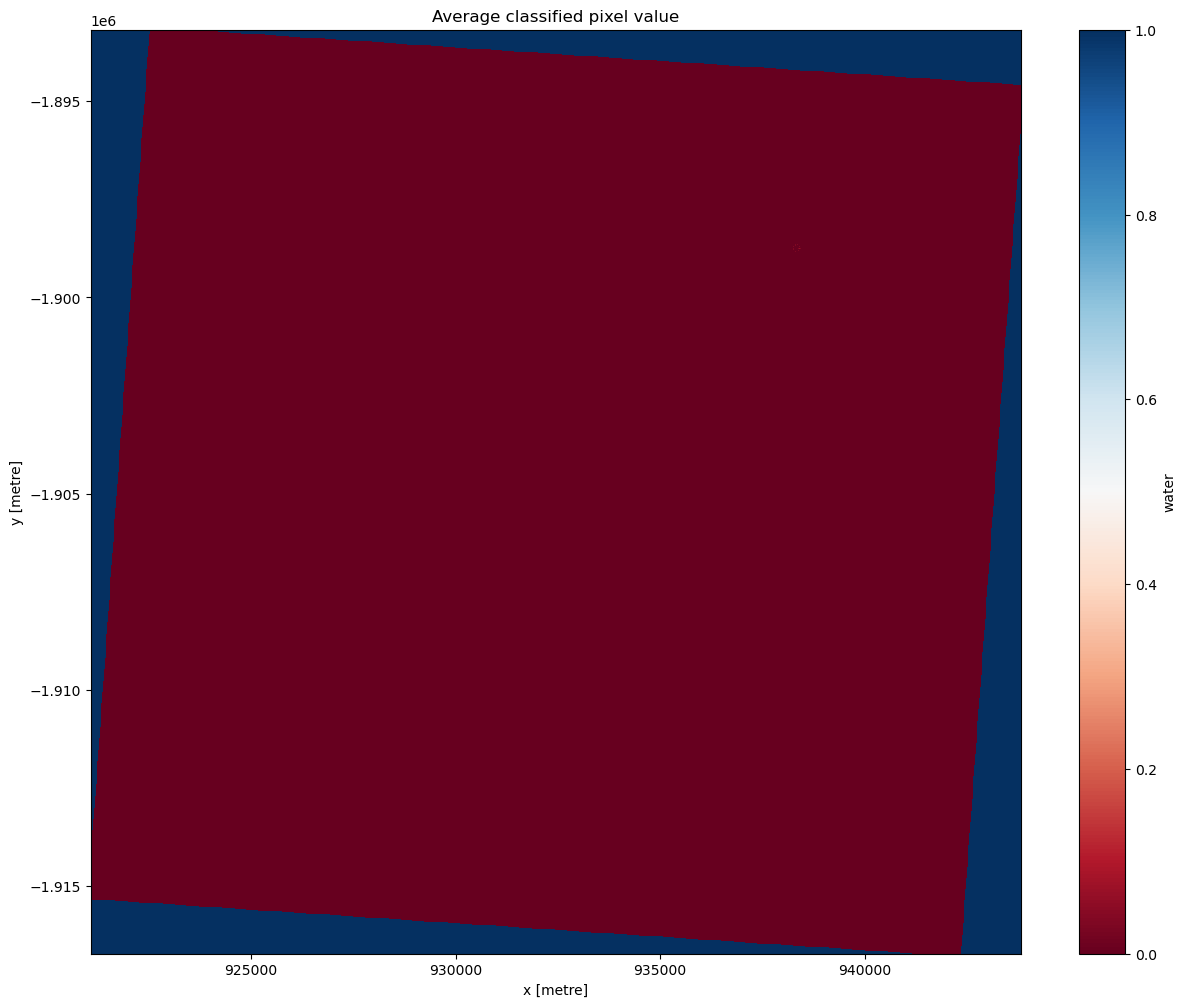

In [74]:
# Plot the mean of each classified pixel value
plt.figure(figsize=(15, 12))
ds_s1.water.mean(dim="time").plot(cmap="RdBu")
plt.title("Average classified pixel value")
plt.show()

#### Interpreting the mean classification 

You can see that our threshold has done a good job of separating the water pixels (in blue) and land pixels (in red). 

You should be able to see that the shoreline takes on a mix of values between `0` and `1`, highlighting pixels that are sometimes land and sometimes water.
This is likely to due the effect of rising and falling tides, with some radar observations being captured at low tide, and others at high tide. 



### Assessment with standard deviation

Given that we've identified the shoreline as the pixels that are calssified sometimes as land and sometimes as water, we can also see if the standard deviation of each pixel in time is a reasonable way to determine if a pixel is shoreline or not.
Similar to how we calculated and plotted the mean above, you can calculate and plot the standard deviation by using the `std` function in place of the `mean` function.

If you'd like to see the results using a different colour-scheme, you can also try substituting `cmap="Greys"` or `cmap="Blues"` in place of `cmap="viridis"`.

In [ ]:
# Plot the standard deviation of each classified pixel value
plt.figure(figsize=(15, 12))
ds_s1.water.std(dim="time").plot(cmap="viridis")
plt.title("Standard deviation of classified pixel values")
plt.show()

#### Interpreting the standard deviation of the classification

From the image above, you should be able to see that the land and water pixels almost always have a standard deviation of `0`, meaning they didn't change over the time we sampled.
Areas along the coastline however have a higher standard deviation, indicating that they change frequently between water and non-water (potentially due to the rise and fall of the tide). 
With further investigation, you could potentially turn this statistic into a new classifier to extract shoreline pixels.
If you're after a challenge, have a think about how you might approach this.

An important thing to recognise is that the standard deviation might not be able to detect the difference between noise, tides and ongoing change, since a pixel that frequently alternates between land and water (noise) could have the same standard deviation as a pixel that is land for some time, then becomes water for the remaining time (ongoing change or tides).
Consider how you might distinguish between these different cases with the data and tools you have.

## Detecting change between two images

The standard deviation we calculated before gives us an idea of how variable a pixel has been over the entire period of time that we looked at.
It might also be interesting to look at which pixels have changed between any two particular times in our sample.

In the next cell, we choose the images to compare.
Printing the dataset should show you that there are 9 time-steps, so the first has an index value of `0`, and the last has an index value of `8`.
You can change these to be any numbers in between, as long as the start is earlier than the end.

In [ ]:
start_time_index = 0
end_time_index = ds_s1.water.sizes["time"] - 1

Next, we can define the change as the difference in the classified pixel value at each point.
Land becoming water will have a value of `-1` and water becoming land will have a value of `1`.

In [ ]:
change = np.subtract(ds_s1.water.isel(time=start_time_index),
                     ds_s1.water.isel(time=end_time_index),
                     dtype=np.float32)

# Set all '0' entries to NaN, which prevents them from displaying in the plot.
change = change.where(change != 0)
ds_s1["change"] = change

Now that we've added change to the dataset, you should be able to plot it below to look at which pixels changed. 
You can also plot the original mean *VH* composite to see how well the change matches our understanding of the shoreline location.


In [ ]:
plt.figure(figsize=(15, 12))
ds_s1.filtered_vh_dB.mean(dim="time").plot(cmap="Blues")
ds_s1.change.plot(cmap="RdBu", levels=2)
plt.title(f"Change in pixel value between time={start_time_index} and time={end_time_index}")
plt.show()

### Coastal change or tides?

Tides can greatly affect the appearance of the coastline, particularly along northern Australia where the tidal range is large (up to 12 m). 
Without additional data, it is difficult to determine whether the change above is due to the coastline having eroded over time, or because the two radar images were captured at different tides (e.g. low vs. high tide).
The radar water classifier in this notebook could potentially be combined with tidal modelling from the [Coastal Erosion notebook](Coastal_erosion.ipynb) to look into this question in more detail.

## Drawing conclusions
Here are some questions to think about:

* What are the benefits and drawbacks of the possible classification options we explored?
* How could you extend the analysis to extract a shape for the coastline?
* How reliable is our classifier?
* Is there anything you can think of that would improve it?

## Next steps

### 1. Select another Australian area using DEA Data

When you are done, return to the "Analysis parameters" section, modify some values (e.g. `latitude` and `longitude`) and rerun the analysis.
You can use the interactive map in the "View the selected location" section to find new central latitude and longitude values by panning and zooming, and then clicking on the area you wish to extract location values for.
You can also use Google maps to search for a location you know, then retrieve the latitude and longitude values by clicking the map.

If you're going to change the location, you'll need to make sure Sentinel-1 data is available for the new location, which you can check on the [DEA Explorer](https://explorer.dea.ga.gov.au/products/s1_gamma0_geotif_scene).

### 2. Investigate Global Areas (excl. Antarctica) using Microsoft Planetary Computer Data

Currently, the DEA datacube has a limited amount of analysis-ready Sentinel-1 data. To extend our analysis to other areas of the globe, we are able to make use of the [Microsoft's Planetary Computer](https://planetarycomputer.microsoft.com/) catalog of satellite and environmental data.
This data is accompanied by detailed [SpatioTemporal Asset Catalog (STAC)](https://stacspec.org/en) metadata, which makes it possible to search and discover data from specific products, time periods and locations of interest.

See more about combining Microsoft Planetary Compute data and DEA data here: [Planetary_computer.ipynb](../How_to_guides/Planetary_computer.ipynb)

See more about the Sentinel-1-RTC product here: https://planetarycomputer.microsoft.com/dataset/sentinel-1-rtc

In [ ]:
# Import extra libraries
import pystac_client
import planetary_computer

import odc.stac
import odc.geo.xr
from odc.geo.geom import BoundingBox

In [ ]:
# this is the same as the top of the notebook, 
# but we can change to other areas of interest
latitude = (-11.288, -11.086)
longitude = (130.324, 130.453)
time = ("2020-01", "2020-02")

In [ ]:
# Open a client pointing to the Microsoft Planetary Computer data catalogue
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [ ]:
# Convert data-cube style queries into something readable by `pystac_client`
bbox = BoundingBox.from_xy(longitude, latitude)
time_range = "/".join(time)

# Search for STAC items from "esa-worldcover" product
search = catalog.search(
    collections="sentinel-1-rtc",
    bbox=bbox,
    datetime=time_range,
)

# Check how many items were returned
items = search.item_collection()
print(f"Found {len(items)} STAC items")

#### Loading data using `odc-stac`

Once we have found some data, we can load it into our notebook using the [odc-stac](https://odc-stac.readthedocs.io/en/latest/?badge=latest) Python library.
The `odc.stac.load` function works similarly to `dc.load`, allowing us to load one or more bands of data into an `xarray.Dataset()`.

Here we will load sentinel-1 RTC data for our study area into Australian Albers 20 m pixels.

> **Note:** The `odc.stac.load` function uses slightly different terminology to `dc.load`, for example: "bands" vs "measurements", "groupby" vs "group_by", "chunks" vs "dask_chunks".

In [ ]:
# Load sentinel-1 RTC data with odc-stac
ds_s1 = odc.stac.load(
    items,
    bbox=bbox,
    crs="EPSG:3577",
    resolution=20,
)

# Inspect outputs
ds_s1

In [ ]:
# Scale to plot data in decibels
ds_s1["vh_dB"] = dB_scale(ds_s1.vh)

# Plot all VH observations for the year
ds_s1.vh_dB.plot(cmap="Greys_r", robust=True, col="time", col_wrap=5)
plt.show()

By changing the latitude and longitude values, we can now extend our analysis to other places.

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** August 2024

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->